In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
#Load dataset
df = pd.read_csv("wfp_food_prices_npl.csv")
df

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,4/15/2001,Province No. 1,DHANKUTA,Dhankuta,647.0,26.98,87.33,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,17.10,0.24
1,4/15/2001,Province No. 1,DHANKUTA,Dhankuta,647.0,26.98,87.33,cereals and tubers,Wheat flour,58.0,KG,actual,Retail,NPR,19.00,0.27
2,4/15/2001,Province No. 1,ILAM,Ilam,649.0,26.91,87.94,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,13.50,0.19
3,4/15/2001,Province No. 1,ILAM,Ilam,649.0,26.91,87.94,cereals and tubers,Wheat flour,58.0,KG,actual,Retail,NPR,16.00,0.22
4,4/15/2001,Province No. 1,JHAPA,Jhapa,661.0,26.48,87.85,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,13.37,0.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41950,6/15/2026,Province No. 7,KAILALI,Dhangadhi,3905.0,28.69,80.66,pulses and nuts,Chickpeas,244.0,KG,actual,Retail,NPR,140.00,0.92
41951,6/15/2026,Province No. 7,KAILALI,Dhangadhi,3905.0,28.69,80.66,vegetables and fruits,Apples,345.0,KG,actual,Retail,NPR,300.00,1.98
41952,6/15/2026,Province No. 7,KAILALI,Dhangadhi,3905.0,28.69,80.66,vegetables and fruits,Carrots,166.0,KG,actual,Retail,NPR,120.00,0.79
41953,6/15/2026,Province No. 7,KAILALI,Dhangadhi,3905.0,28.69,80.66,vegetables and fruits,Mustard leaves,1222.0,KG,actual,Retail,NPR,120.00,0.79


In [3]:
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,4/15/2001,Province No. 1,DHANKUTA,Dhankuta,647.0,26.98,87.33,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,17.10,0.24
1,4/15/2001,Province No. 1,DHANKUTA,Dhankuta,647.0,26.98,87.33,cereals and tubers,Wheat flour,58.0,KG,actual,Retail,NPR,19.00,0.27
2,4/15/2001,Province No. 1,ILAM,Ilam,649.0,26.91,87.94,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,13.50,0.19
3,4/15/2001,Province No. 1,ILAM,Ilam,649.0,26.91,87.94,cereals and tubers,Wheat flour,58.0,KG,actual,Retail,NPR,16.00,0.22
4,4/15/2001,Province No. 1,JHAPA,Jhapa,661.0,26.48,87.85,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,13.37,0.19


In [4]:
df.shape

(41955, 16)

In [5]:
#dataset exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41955 entries, 0 to 41954
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          41955 non-null  object 
 1   admin1        41955 non-null  object 
 2   admin2        41955 non-null  object 
 3   market        41955 non-null  object 
 4   market_id     41954 non-null  float64
 5   latitude      41955 non-null  float64
 6   longitude     41955 non-null  float64
 7   category      41955 non-null  object 
 8   commodity     41953 non-null  object 
 9   commodity_id  41954 non-null  float64
 10  unit          41955 non-null  object 
 11  priceflag     41955 non-null  object 
 12  pricetype     41955 non-null  object 
 13  currency      41955 non-null  object 
 14  price         41952 non-null  float64
 15  usdprice      41953 non-null  float64
dtypes: float64(6), object(10)
memory usage: 5.1+ MB


In [6]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,41954.000000,41955.000000,41955.000000,41954.000000,41952.000000,41953.000000
mean,3172.327025,28.095479,83.763858,184.982385,147.036691,1.163577
std,1325.914787,0.994665,2.156366,125.808770,136.364021,1.053694
min,645.000000,26.450000,80.660000,58.000000,6.000000,0.058000
25%,3833.000000,27.120000,81.920000,85.000000,50.000000,0.440000
50%,3854.000000,28.210000,83.440000,166.000000,100.000000,0.780000
75%,3887.000000,28.930000,85.320000,254.000000,200.000000,1.540000
max,3913.000000,30.130000,87.940000,1222.000000,1200.000000,10.070000


In [7]:
#check for missing values
df.isnull().sum()

date            0
admin1          0
admin2          0
market          0
market_id       1
latitude        0
longitude       0
category        0
commodity       2
commodity_id    1
unit            0
priceflag       0
pricetype       0
currency        0
price           3
usdprice        2
dtype: int64

In [8]:
df = df.dropna() #if they are missing values

In [9]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

In [11]:
#data cleaning
df["date"] = pd.to_datetime(df["date"])

In [12]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month

In [13]:
#check the cleaned dataset
print(df.shape)
df.info()
df.head()

(41946, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 41946 entries, 0 to 41954
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          41946 non-null  datetime64[ns]
 1   admin1        41946 non-null  object        
 2   admin2        41946 non-null  object        
 3   market        41946 non-null  object        
 4   market_id     41946 non-null  float64       
 5   latitude      41946 non-null  float64       
 6   longitude     41946 non-null  float64       
 7   category      41946 non-null  object        
 8   commodity     41946 non-null  object        
 9   commodity_id  41946 non-null  float64       
 10  unit          41946 non-null  object        
 11  priceflag     41946 non-null  object        
 12  pricetype     41946 non-null  object        
 13  currency      41946 non-null  object        
 14  price         41946 non-null  float64       
 15  usdprice      41946 non-null 

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,Year,Month
0,2001-04-15,Province No. 1,DHANKUTA,Dhankuta,647.0,26.98,87.33,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,17.10,0.24,2001,4
1,2001-04-15,Province No. 1,DHANKUTA,Dhankuta,647.0,26.98,87.33,cereals and tubers,Wheat flour,58.0,KG,actual,Retail,NPR,19.00,0.27,2001,4
2,2001-04-15,Province No. 1,ILAM,Ilam,649.0,26.91,87.94,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,13.50,0.19,2001,4
3,2001-04-15,Province No. 1,ILAM,Ilam,649.0,26.91,87.94,cereals and tubers,Wheat flour,58.0,KG,actual,Retail,NPR,16.00,0.22,2001,4
4,2001-04-15,Province No. 1,JHAPA,Jhapa,661.0,26.48,87.85,cereals and tubers,Rice (coarse),60.0,KG,actual,Retail,NPR,13.37,0.19,2001,4


In [14]:
#saved the cleaned dataset
df.to_csv("wfp_food_prices_npl_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41946 entries, 0 to 41954
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          41946 non-null  datetime64[ns]
 1   admin1        41946 non-null  object        
 2   admin2        41946 non-null  object        
 3   market        41946 non-null  object        
 4   market_id     41946 non-null  float64       
 5   latitude      41946 non-null  float64       
 6   longitude     41946 non-null  float64       
 7   category      41946 non-null  object        
 8   commodity     41946 non-null  object        
 9   commodity_id  41946 non-null  float64       
 10  unit          41946 non-null  object        
 11  priceflag     41946 non-null  object        
 12  pricetype     41946 non-null  object        
 13  currency      41946 non-null  object        
 14  price         41946 non-null  float64       
 15  usdprice      41946 non-null  float64    

In [16]:
#feature engineering
df = df.sort_values(["market", "commodity", "date"])

In [17]:
#Create Previous Price.
df["Previous_Price"] = (
    df.groupby(["market", "commodity"])["price"]
      .shift(1)
)

In [18]:
#create variable target
df["Price_Change"] = (
    df["price"] >
    df["Previous_Price"]
).astype(int)

In [19]:
#Remove missing Previous Price.
df = df.dropna(subset=["Previous_Price"])

In [20]:
print(df.select_dtypes(include="object").columns)

Index(['admin1', 'admin2', 'market', 'category', 'commodity', 'unit',
       'priceflag', 'pricetype', 'currency'],
      dtype='object')


In [21]:
#Encode Categorical Variables
encoder = LabelEncoder()

categorical_columns = [
    "admin1",
    "admin2",
    "market",
    "category",
    "commodity",
    "unit",
    "priceflag",
    "pricetype"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [22]:
df = df.drop(columns=["currency"], errors="ignore")

In [23]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


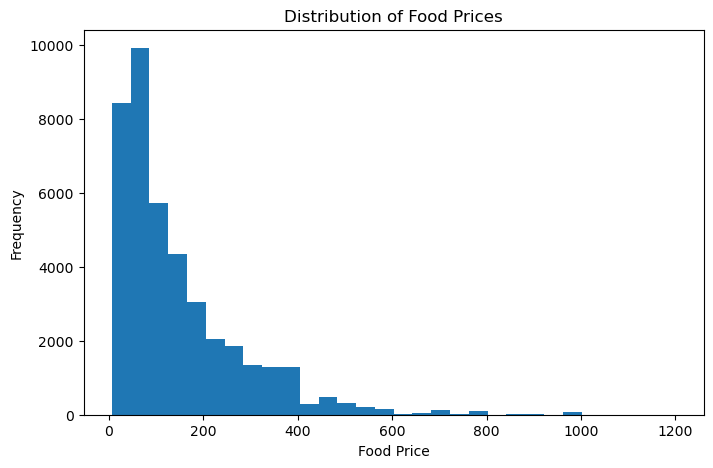

In [24]:
#Exploratory Data Analysis [Plot Histogram]
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Distribution of Food Prices")
plt.xlabel("Food Price")
plt.ylabel("Frequency")

plt.show()

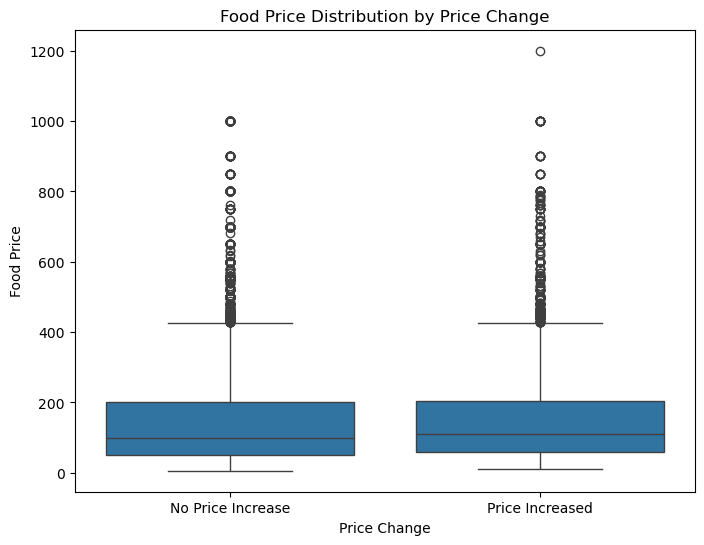

In [25]:
#visualize box plot
plot_df = df.copy()

plot_df["Price_Change_Label"] = plot_df["Price_Change"].map({
    0: "No Price Increase",
    1: "Price Increased"
})

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Price_Change_Label",
    y="price",
    data=plot_df
)

plt.title("Food Price Distribution by Price Change")
plt.xlabel("Price Change")
plt.ylabel("Food Price")

plt.show()

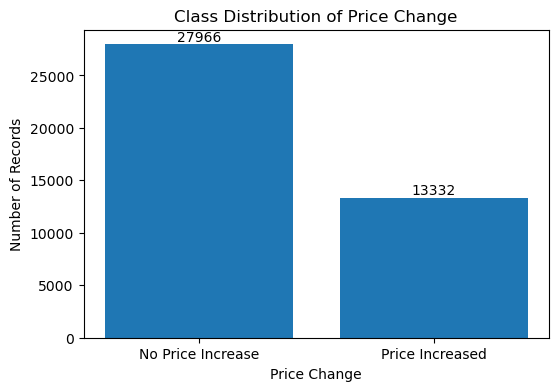

In [26]:
#class distribution visualization
# Count the classes
class_counts = df["Price_Change"].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
plt.bar(
    ["No Price Increase", "Price Increased"],
    class_counts.values
)

plt.title("Class Distribution of Price Change")
plt.xlabel("Price Change")
plt.ylabel("Number of Records")

# Display the count on top of each bar
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 300, str(count), ha='center', fontsize=10)

plt.show()

In [27]:
#Handling outliers
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower) |
    (df["price"] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 1737


In [28]:
#feature selection
X = df.drop(columns=[
    "Price_Change",
    "date",
    "price",
    "usdprice"
])

y = df["Price_Change"]

In [29]:
#Time-Based Train-Test Split
df = df.sort_values("date")

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [30]:
X_train = train.drop(columns=[
    "Price_Change",
    "date",
    "price",
    "usdprice"
])

X_test = test.drop(columns=[
    "Price_Change",
    "date",
    "price",
    "usdprice"
])

y_train = train["Price_Change"]
y_test = test["Price_Change"]

In [31]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [32]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
#make predictions
dt_predictions = dt_model.predict(X_test)

In [35]:
#evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, dt_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Accuracy: 0.7323244552058111

Confusion Matrix:
[[5689  441]
 [1770  360]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.84      6130
           1       0.45      0.17      0.25      2130

    accuracy                           0.73      8260
   macro avg       0.61      0.55      0.54      8260
weighted avg       0.68      0.73      0.68      8260



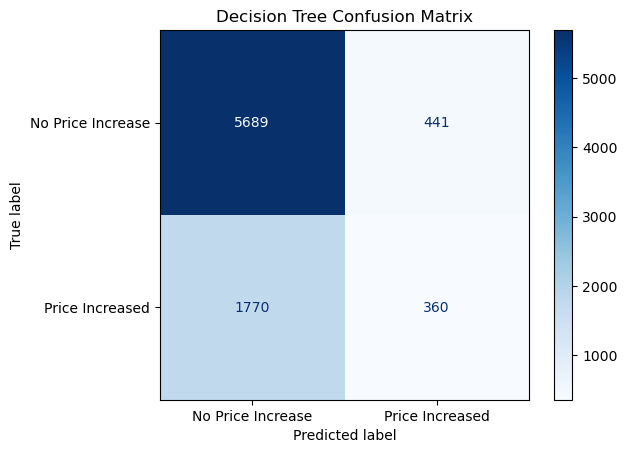

[[5689  441]
 [1770  360]]


In [36]:
#confusion matrix of Decision Tree
# Prediction
dt_pred = dt_model.predict(X_test)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Price Increase", "Price Increased"]
)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

print(cm_dt)

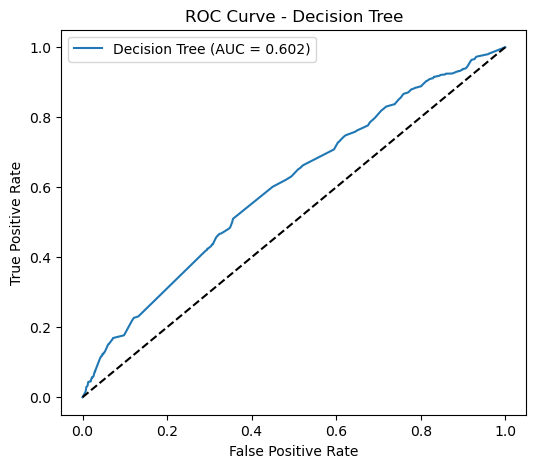

Decision Tree AUC: 0.6017422588822767


In [37]:
#decision tree
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
dt_probs = dt_model.predict_proba(X_test)[:,1]

# ROC values
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
auc_dt = roc_auc_score(y_test, dt_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

print("Decision Tree AUC:", auc_dt)

In [38]:
#decision tree error analysis
dt_pred = dt_model.predict(X_test)

misclassified_dt = X_test.copy()
misclassified_dt["Actual"] = y_test.values
misclassified_dt["Predicted"] = dt_pred

misclassified_dt = misclassified_dt[
    misclassified_dt["Actual"] != misclassified_dt["Predicted"]
]

misclassified_dt.head(5)

,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,Year,Month,Previous_Price,Actual,Predicted
33873,5,28,5,3848.0,28.60,81.64,1,11,94.0,1,0,0,2025,1,430.0,1,0
33662,2,17,14,3833.0,27.42,85.03,1,6,92.0,3,0,0,2025,1,20.0,1,0
33669,2,17,14,3833.0,27.42,85.03,6,5,244.0,1,0,0,2025,1,160.0,1,0
33850,5,25,28,3858.0,28.61,82.48,0,20,60.0,1,0,0,2025,1,75.0,1,0
33586,1,22,6,3874.0,27.08,84.90,1,6,92.0,3,0,0,2025,1,18.0,1,0


In [39]:
#Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
#random forest predictions
rf_predictions = rf_model.predict(X_test)

In [41]:
#evaluate the random forest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7435835351089588

Confusion Matrix
[[5937  193]
 [1925  205]]

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.97      0.85      6130
           1       0.52      0.10      0.16      2130

    accuracy                           0.74      8260
   macro avg       0.64      0.53      0.51      8260
weighted avg       0.69      0.74      0.67      8260



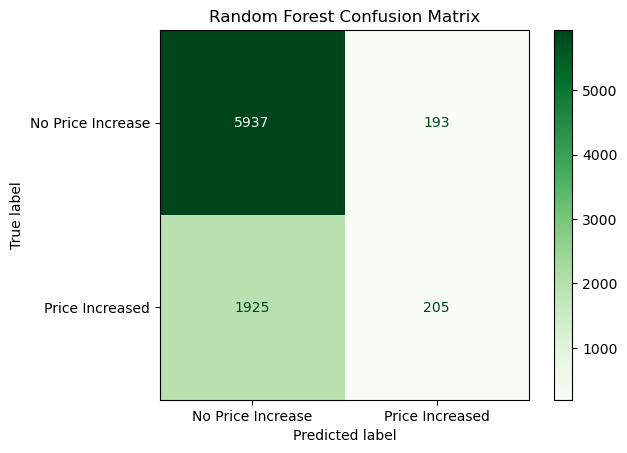

[[5937  193]
 [1925  205]]


In [42]:
#confusion matrix of Random Forest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Prediction random forest
rf_pred = rf_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Price Increase", "Price Increased"]
)

disp.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

print(cm_rf)

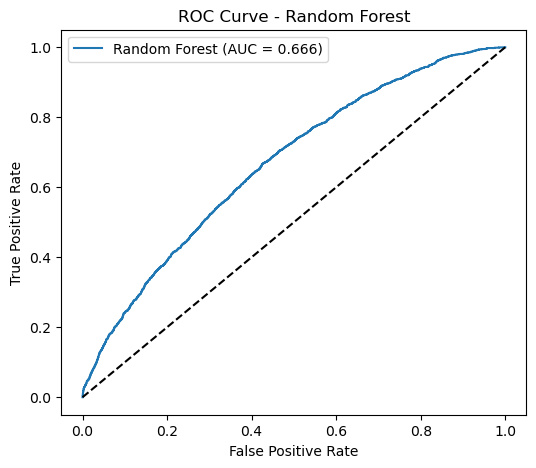

Random Forest AUC: 0.6661807550031018


In [43]:
# Probability predictions
rf_probs = rf_model.predict_proba(X_test)[:,1]

# ROC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("Random Forest AUC:", auc_rf)

In [44]:
#random forest error analysis
rf_pred = rf_model.predict(X_test)

misclassified_rf = X_test.copy()
misclassified_rf["Actual"] = y_test.values
misclassified_rf["Predicted"] = rf_pred

misclassified_rf = misclassified_rf[
    misclassified_rf["Actual"] != misclassified_rf["Predicted"]
]

misclassified_rf.head(5)

,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,Year,Month,Previous_Price,Actual,Predicted
33873,5,28,5,3848.0,28.60,81.64,1,11,94.0,1,0,0,2025,1,430.0,1,0
33662,2,17,14,3833.0,27.42,85.03,1,6,92.0,3,0,0,2025,1,20.0,1,0
33669,2,17,14,3833.0,27.42,85.03,6,5,244.0,1,0,0,2025,1,160.0,1,0
33606,1,27,35,3884.0,26.54,86.77,1,11,94.0,1,0,0,2025,1,280.0,0,1
33850,5,25,28,3858.0,28.61,82.48,0,20,60.0,1,0,0,2025,1,75.0,1,0
